# CircLS pipeline, end to end: toffoli_n3

The Toffoli gate on 3 qubits, the program of the paper's Table 2 row `toffoli_n3` (d = 3).
It is a non-Clifford program: 7 T gates, each lowered to a magic-state gadget.  For sampling, every
|T> state is replaced by an |+> state (the paper's X-state proxy).  The proxy changes nothing the
compiler sees: the PPM sequence, the gadgets, and every mapping and routing decision except the ancilla
orientation are the ones the real program gets; only the resource state differs, so the circuit stays Clifford and stim can sample it.
One compiler rule postdates the paper's runs: each |+> ancilla is born facing the step that consumes it
(the paper pinned every ancilla to one orientation), so the volume here is below the Table 2 cell and
the orientation is the one decision the proxy makes for itself (a |Y>-born ancilla stays pinned).

The notebook walks the pipeline in order: QASM -> NWQEC -> canonical form of the PPM program -> mapping,
routing and dynamic allocation -> TQEC block graph -> stim circuits -> logical error rate.  The compiler is
run in the paper's configuration: optimized mapping, first-use initialization, last-use freeing and
terminal-measurement re-selection.  The compiler's other optional passes (the lifetime-aware step scheduler
and parallel merge windows) are switched off.

## 1. The logical circuit

In [1]:
import pathlib, sys, os, json, contextlib, io
HERE = pathlib.Path.cwd()
ROOT = pathlib.Path(os.environ.get("CIRCLS_ROOT", HERE.parents[2]))
for p in (str(ROOT), str(ROOT / "experiments"), str(ROOT / "gallery" / "tools")):
    if p not in sys.path:
        sys.path.insert(0, p)
for sub in ("data", "figures", "stim", "blockgraph"):
    (HERE / sub).mkdir(exist_ok=True)

qasm = pathlib.Path("data/1_toffoli_n3.qasm").read_text()
GATES = [l for l in qasm.splitlines()
         if l and not l.startswith(("OPENQASM", "include", "qreg", "creg", "measure"))]
print(f"Toffoli on 3 qubits (QASMBench toffoli_n3, TopoLS's tt2 transpilation), {len(GATES)} gates, "
      f"{sum(g.startswith(('t ', 'tdg ')) for g in GATES)} of them T or T-dagger")
print(qasm)

Toffoli on 3 qubits (QASMBench toffoli_n3, TopoLS's tt2 transpilation), 17 gates, 7 of them T or T-dagger
OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
x q[0];
x q[1];
h q[2];
cx q[1], q[2];
t q[2];
cx q[0], q[2];
t q[2];
cx q[1], q[2];
t q[2];
cx q[0], q[2];
t q[1];
t q[2];
cx q[0], q[1];
h q[2];
t q[1];
cx q[0], q[1];
t q[0];
creg c[3];
measure q -> c;



## 2. NWQEC: QASM to a Pauli-based circuit

NWQEC turns the gate list into Pauli rotations plus terminal measurements.  Each T becomes a pi/8
rotation; with the proxy it is read as a pi/4 rotation (`t_as_s`), so the sequence below has only
`s` rotations and terminal `m` measurements.  This stage is not part of CircLS: any front end that
produces such a sequence can be plugged in here.

In [2]:
from circls.interop.nwqec.frontend import load_clifford_t_as_s
from nb_helpers import show_ops, save_ops
pbc = load_clifford_t_as_s(qasm)
save_ops(pbc, "data/2_toffoli_n3_nwqec_pbc.txt")
kinds = {}
for o in pbc.ops: kinds[o.kind] = kinds.get(o.kind, 0) + 1
print(f"{len(pbc.ops)} ops: {kinds}")
show_ops(pbc, limit=12, tail=4)

10 ops: {'s': 7, 'm': 3}


$(\mathbb{1} \otimes Z \otimes X)_{-\pi/4}$  
$(Z \otimes Z \otimes X)_{\pi/4}$  
$(Z \otimes \mathbb{1} \otimes X)_{-\pi/4}$  
$(\mathbb{1} \otimes Z \otimes \mathbb{1})_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
$(Z \otimes Z \otimes \mathbb{1})_{\pi/4}$  
$(Z \otimes \mathbb{1} \otimes \mathbb{1})_{-\pi/4}$  
$-Z \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes Z \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes Z$ measurement

## 3. Canonical form of the PPM program

Three fixed rewrites run on the sequence before any placement.  Terminal-measurement re-selection
replaces the set of terminal measurements by products of lower weight (a greedy weight-reduction sweep;
exact, the original outcomes are reconstructed from the executed ones).  Weight-1 operations are moved
last.  The Y-free rewrite turns every Y axis into X/Z at the cost of extra pi/4 rotations.  Gadget
expansion then turns every pi/4 rotation into an ancilla patch, one joint PPM and a readout; the PPM
sequence is born in that step.  The step scheduler is not applied (paper configuration).


In [3]:
from circls.compiler.measure_reduce import reduce_measurements
from circls.interop.ir.pauli_ir import PauliCircuit
from circls.pipeline import reorder_weight1_last, drop_free_prefix, y_free_sweep, expand_gadgets

s_head = [o for o in pbc.ops if o.kind != "m"]
m_only = PauliCircuit(pbc.num_qubits, [o for o in pbc.ops if o.kind == "m"])
reduced, _ = reduce_measurements(m_only)           # terminal-measurement re-selection (paper configuration)
save_ops(reduced, "data/3_toffoli_n3_reselected.txt")
ordered, _ = reorder_weight1_last(reduced)         # the terminal measurements, weight-1 ones last
merged = PauliCircuit(ordered.num_qubits, list(s_head) + list(ordered.ops))
yfree = drop_free_prefix(y_free_sweep(merged))
save_ops(yfree, "data/3_toffoli_n3_yfree.txt")
program = expand_gadgets(yfree)
w = lambda c: sum(o.weight for o in c.ops if o.kind == "m")
print(f"NWQEC output          {len(pbc.ops):3d} ops  ({len(s_head)} rotations + {len(m_only.ops)} terminal measurements, total weight {w(m_only)})")
print(f"after re-selection    {len(s_head) + len(reduced.ops):3d} ops  ({len(reduced.ops)} terminal measurements, total weight {w(reduced)})")
print(f"after Y-free rewrite  {len(yfree.ops):3d} ops")
print(f"PPM program           {len(program.ops):3d} ops, {len(program.gadgets)} gadgets")

NWQEC output           10 ops  (7 rotations + 3 terminal measurements, total weight 3)
after re-selection     10 ops  (3 terminal measurements, total weight 3)
after Y-free rewrite   10 ops
PPM program            24 ops, 7 gadgets


## 4. CircLS compilation: mapping, routing, dynamic allocation

`compile_qasm` runs sections 2 and 3 again internally and then does the compiler's own work: the
mapper places the patches (`assignment="optimized"`), the router draws one ancilla path per PPM
through the free tiles, one PPM per merge window, and dynamic allocation initializes each patch at its
first use and frees it at its last use.  `KW` is the paper's configuration: terminal-measurement re-selection on, the
step scheduler and parallel windows off.  `magic_proxy="X"` is the paper's X-state proxy: gadget ancillas are prepared in |+>
instead of |Y>, and each is born facing the step that consumes it (Z through an E/W seam
wants `X_horizontal`, through a N/S seam `X_vertical`), so its corridor attaches on the near
side; a tied vote is settled by the assignment's exact corridor judge.  The paper's runs pinned
every ancilla to `X_vertical`; this rule was added on 2026-09-25 after Austin Fowler pointed out
the detours it caused, so the volume below is smaller than the paper's Table 2 cell (83.0).

In [4]:
import circls.pipeline as P
from ablation import compile_kwargs
from benchsuite import tclass_suite
from nb_helpers import ppm_step_lines
case = {c.name: c for c in tclass_suite()}["toffoli_n3"]
KW = compile_kwargs("full", case)
KW.update(measure_reduction=True, step_scheduling=False, parallel_steps=False)    # paper configuration
KW["magic_proxy"] = "X"      # the paper's X-state proxy: gadget ancillas born in |+>, each facing the step that consumes it

def compile_d(d):
    with contextlib.redirect_stdout(io.StringIO()):
        return P.compile_qasm(qasm, distance=d, t_as_s=True, **KW)

cp3 = compile_d(3)
steps = cp3.experiment.ppm_sequence
pathlib.Path("data/4_toffoli_n3_ppm_sequence.txt").write_text("\n".join(ppm_step_lines(steps)) + "\n")
print(f"{len(steps)} executed PPMs; y0..y6 are the |+> ancillas standing in for the 7 T states")
print("\n".join(ppm_step_lines(steps)))

7 executed PPMs; y0..y6 are the |+> ancillas standing in for the 7 T states
PPM 0: q1.Z  q2.X  y0.Z
PPM 1: q0.Z  q1.Z  q2.X  y1.Z
PPM 2: q0.Z  q2.X  y2.Z
PPM 3: q1.Z  y3.Z
PPM 4: q2.X  y4.Z
PPM 5: q0.Z  q1.Z  y5.Z
PPM 6: q0.Z  y6.Z


## 5. Placement, routed ancilla paths, and the 3D spacetime structure

10 patches placed, 7 PPM steps (7 joint) routed; full detail in 5_toffoli_n3_placement_routing.json


3D structure: 5_toffoli_n3_spacetime.png (75.0 blocks; the paper's Table 2 cell for toffoli_n3, d = 3, is 83.0 with the ancilla orientation pinned)


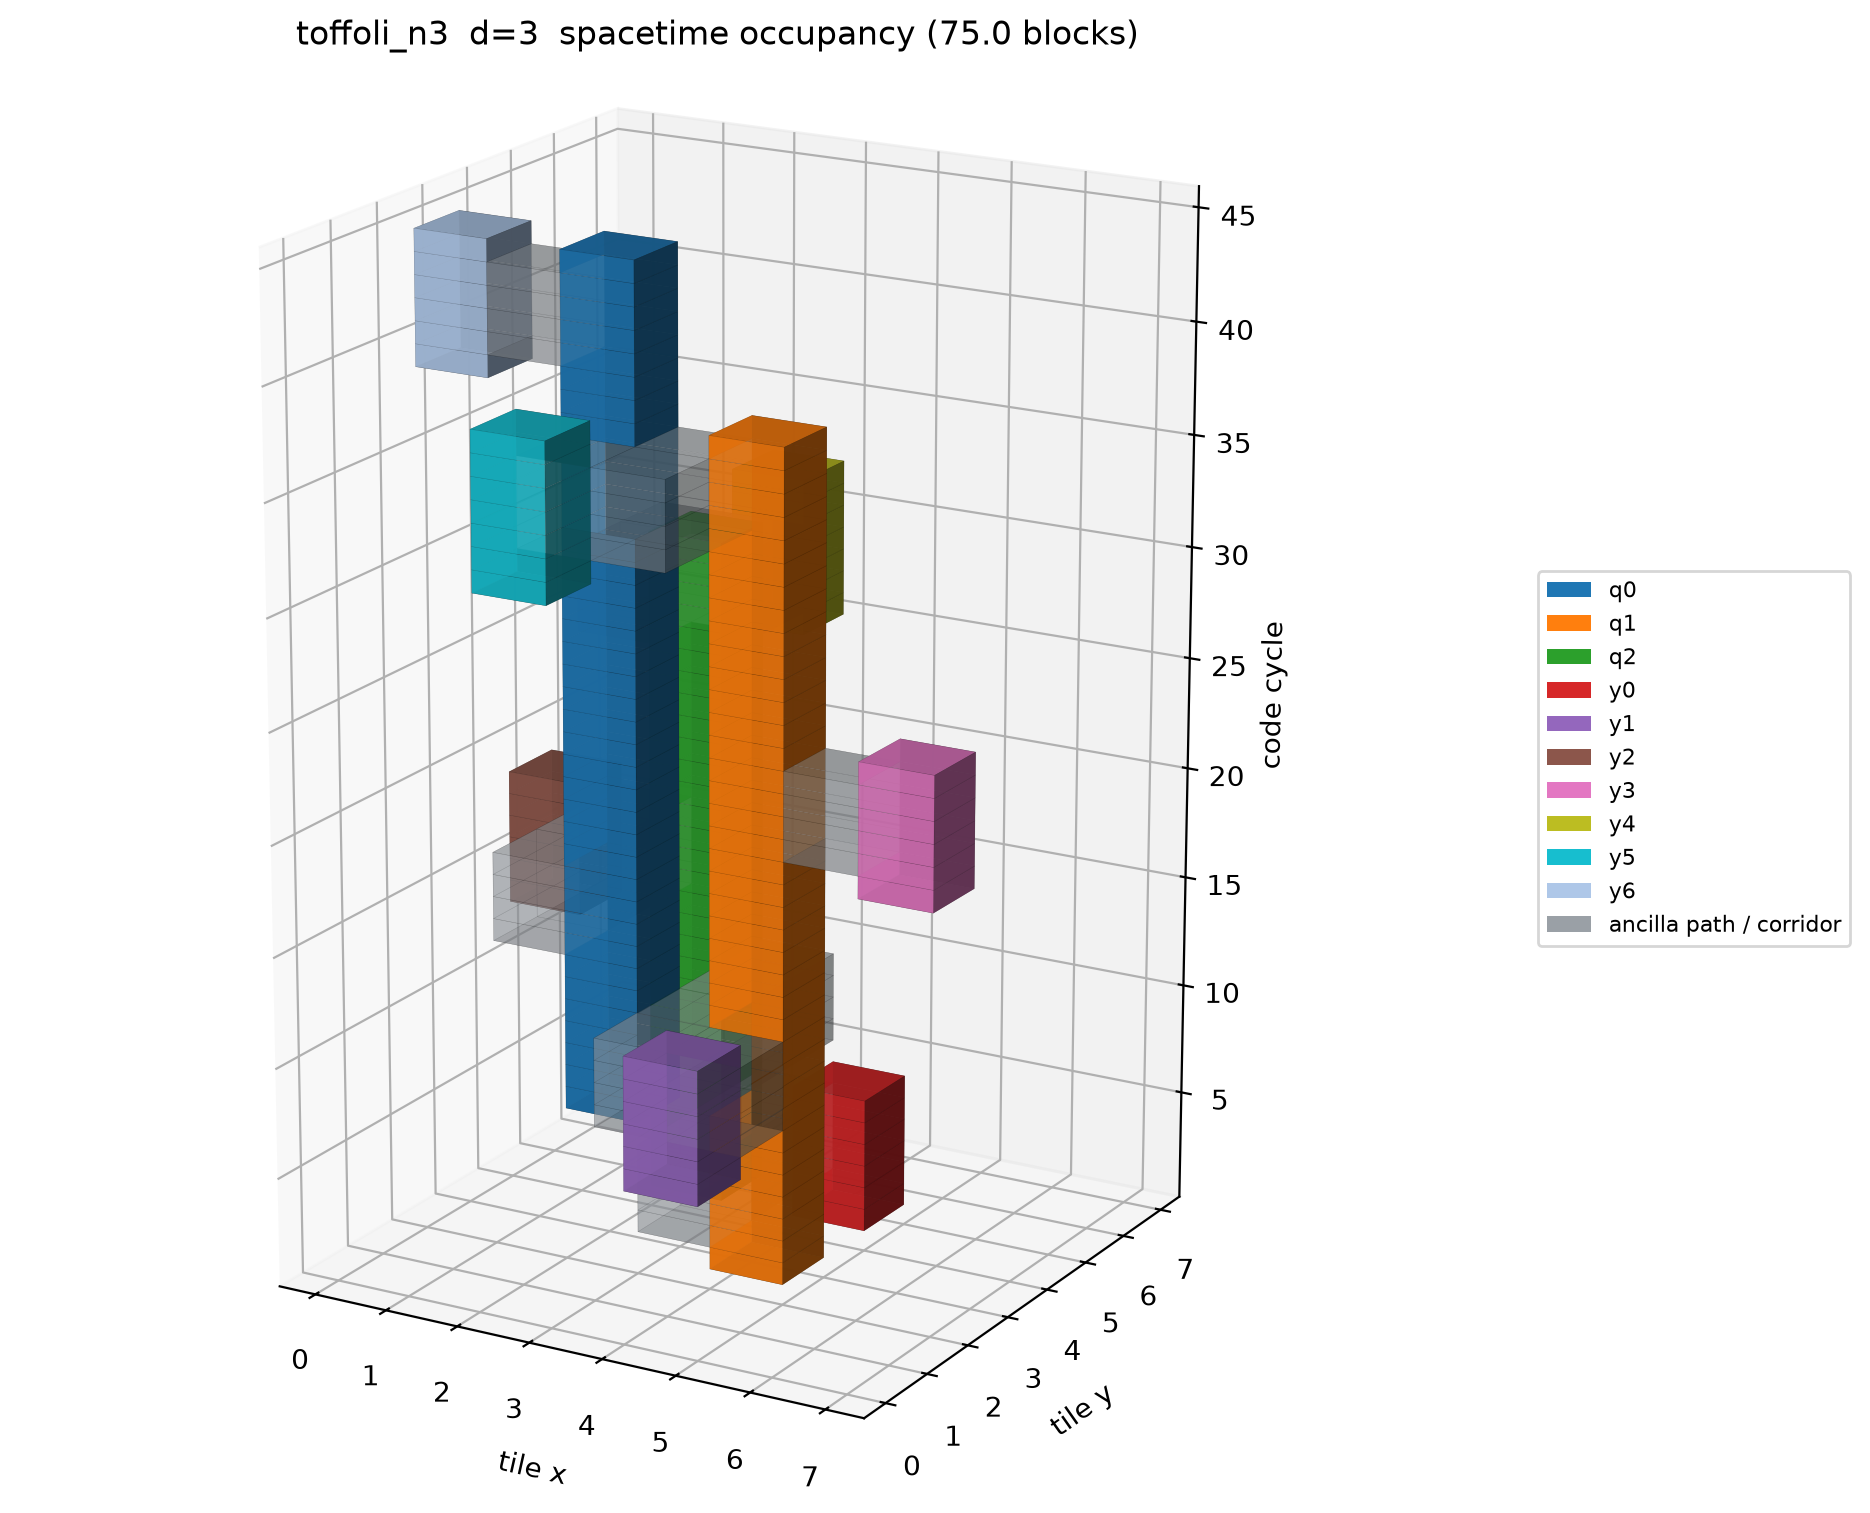

In [5]:
from circls.metrics.experiment_stats import experiment_stats
from render_spacetime import render
from nb_helpers import save_routing
import shutil
print(save_routing(cp3, steps, "data/5_toffoli_n3_placement_routing.json"))
stats = experiment_stats(cp3.experiment, cp3.circuit)
png, js, _ = render(stats, cp3.placement, "toffoli_n3", str(HERE / "figures"), distance=3)
shutil.move(str(HERE / "figures" / "toffoli_n3_schedule.json"), str(HERE / "data" / "5_toffoli_n3_schedule.json"))
png2 = str(HERE / "figures" / "5_toffoli_n3_spacetime.png"); shutil.move(png, png2); png = png2
print("3D structure:", pathlib.Path(png).name, f"({stats.volume_blocks:.1f} blocks; the paper's Table 2 cell for toffoli_n3, d = 3, is 83.0 with the ancilla orientation pinned)")
from IPython.display import Image, display
display(Image(png, width=640))

## 6. TQEC block-graph export (rotatable)

The schedule is translated into tqec's block graph: one cube layer per scheduling batch, a patch's
live range as a column of cubes, each merge as corridor cubes piped to the patches it joins.  Where a
patch touches more than one corridor tile the seam can sit on either side; the exporter searches those
choices and keeps the first embedding that satisfies tqec's wall rules.  The result is validated with
tqec's own toolchain (`blockgraph/tqec_validation.txt`).

-> blockgraph/toffoli_n3_blockgraph.html: 63 cubes, 65 pipes -- drag to rotate (the .dae loads into tqec / SketchUp)


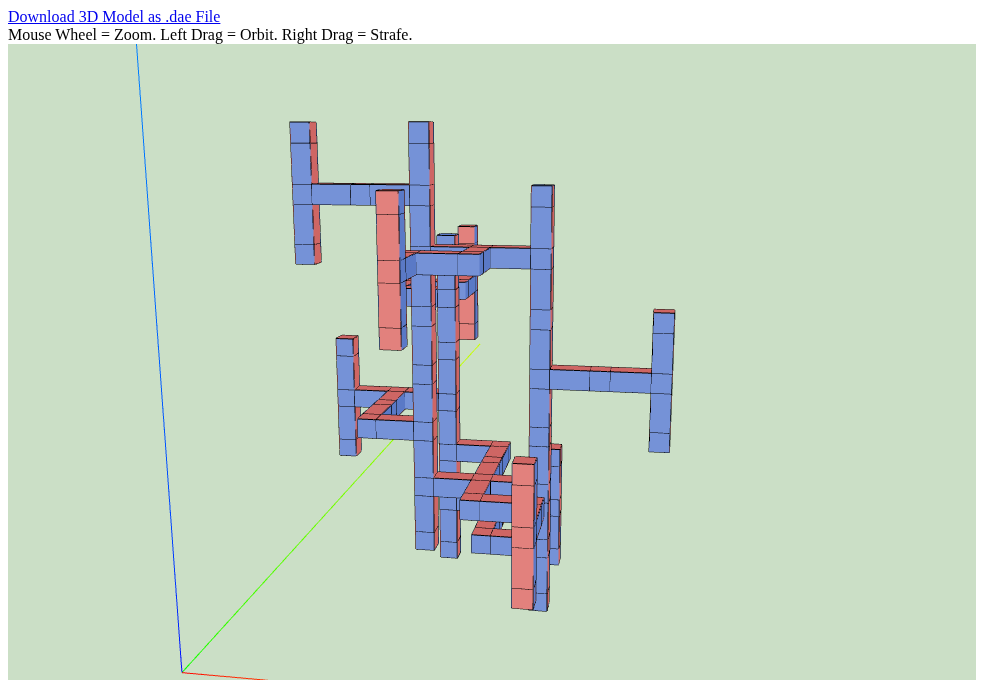

In [6]:
from export_blockgraph_auto import auto_export
BG = HERE / "blockgraph"
if not list(BG.glob("*_blockgraph.dae")):
    auto_export(cp3, "toffoli_n3", BG, tqec_python=os.environ.get("TQEC_PYTHON"))
hits = sorted(BG.glob("*_blockgraph.html"))
from IPython.display import IFrame, Image, display
if hits:
    bs = json.loads((BG / "toffoli_n3_blockstructure.json").read_text())
    print(f"-> blockgraph/{hits[0].name}: {len(bs['cubes'])} cubes, {len(bs['pipes'])} pipes -- drag to rotate "
          f"(the .dae loads into tqec / SketchUp)")
    snap = HERE / "figures" / "6_toffoli_n3_blockgraph.png"
    if snap.exists():
        display(Image(str(snap), width=640))
    display(IFrame("blockgraph/" + hits[0].name, width=760, height=480))
else:
    print((BG / "export_log.txt").read_text())

## 7. stim circuits: clean and noisy, d = 3, 5, 7

In [7]:
from noise_inject import inject_uniform_noise
P_NOISY = 1e-3
circuits = {}
for d in (3, 5, 7):
    cp = cp3 if d == 3 else compile_d(d)
    clean = cp.circuit
    circuits[d] = clean
    (HERE / "stim" / f"d{d}").mkdir(exist_ok=True)
    pathlib.Path(f"stim/d{d}/7_toffoli_n3_clean.stim").write_text(str(clean))
    pathlib.Path(f"stim/d{d}/7_toffoli_n3_noisy_p1e-3.stim").write_text(str(inject_uniform_noise(clean, P_NOISY)))
    print(f"d={d}: {clean.num_qubits} qubits, {clean.num_detectors} detectors, {clean.num_observables} observables")

d=3: 520 qubits, 1498 detectors, 5 observables


d=5: 1314 qubits, 6556 detectors, 5 observables


d=7: 2460 qubits, 17246 detectors, 5 observables


## 8. Measured logical error rate of the CircLS-compiled circuits

PyMatching, d = 3, 5, 7 at p = 5e-4 .. 2e-2, circuit-level depolarizing noise.  The d = 3 and d = 5
points at p = 5e-4 are the LER cells of this gallery configuration; the paper's Table 2 cells, compiled
with the ancilla orientation pinned, were 0.062 and 0.0098.

d=3 p=0.0005: LER=0.056  (2800 errors / 50000 shots)
d=3 p=0.001: LER=0.1887  (9433 errors / 50000 shots)
d=3 p=0.002: LER=0.4808  (24038 errors / 50000 shots)
d=3 p=0.01: LER=0.8714  (43570 errors / 50000 shots)
d=3 p=0.02: LER=0.8749  (43745 errors / 50000 shots)
d=5 p=0.0005: LER=0.00872  (436 errors / 50000 shots)
d=5 p=0.001: LER=0.05818  (2909 errors / 50000 shots)
d=5 p=0.002: LER=0.3337  (16685 errors / 50000 shots)
d=5 p=0.01: LER=0.8759  (43796 errors / 50000 shots)
d=5 p=0.02: LER=0.8745  (43724 errors / 50000 shots)
d=7 p=0.0005: LER=0.00106  (106 errors / 100000 shots)
d=7 p=0.001: LER=0.01564  (782 errors / 50000 shots)
d=7 p=0.002: LER=0.1995  (9975 errors / 50000 shots)
d=7 p=0.01: LER=0.8768  (43839 errors / 50000 shots)
d=7 p=0.02: LER=0.8728  (43639 errors / 50000 shots)


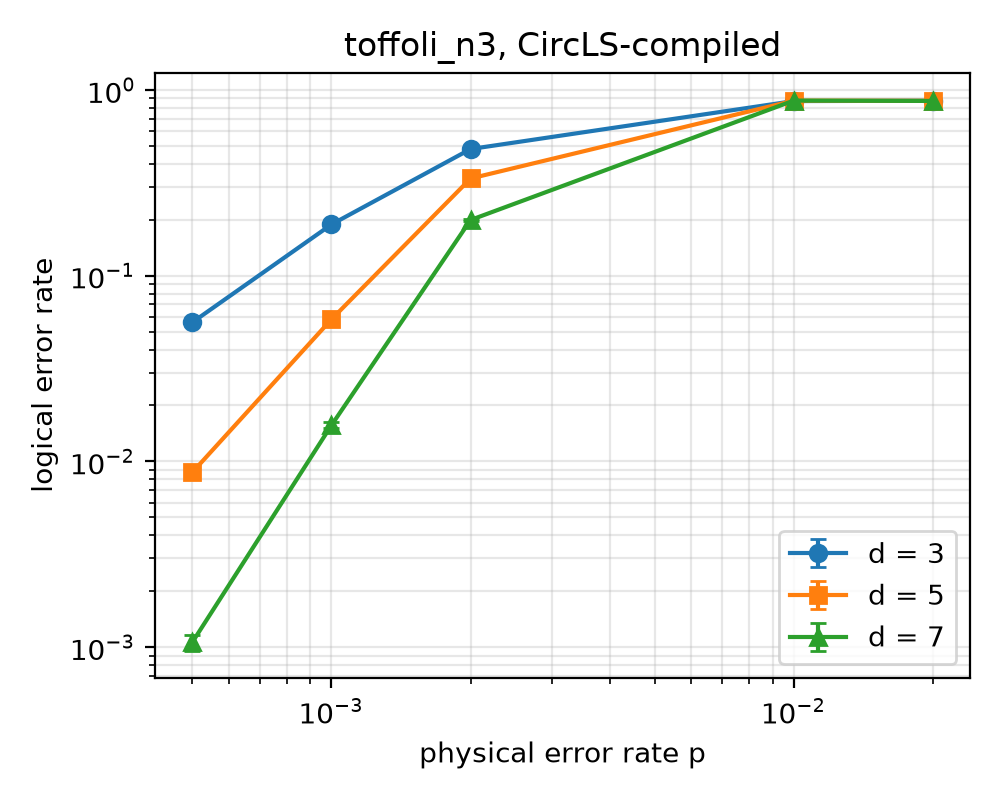

In [8]:
from ler_sampler import measure_ler
from nb_helpers import save_ler_points, plot_ler
PS = [5e-4, 1e-3, 2e-3, 1e-2, 2e-2]
WORKERS = 32     # parallel sampling processes -- set to your machine
pts_file = pathlib.Path("data/8_toffoli_n3_ler_points.json")
if pts_file.exists():           # precomputed by this notebook's last full run; delete the file to resample
    raw = json.loads(pts_file.read_text())      # keys look like "d3_p0.0005"
    points = {(int(k.split("_p")[0][1:]), float(k.split("_p")[1])): (v["ler"], v["errors"], v["shots"])
              for k, v in raw.items()}
else:
    points = {(d, p): measure_ler(inject_uniform_noise(clean, p), workers=WORKERS)
              for d, clean in circuits.items() for p in PS}
    save_ler_points(points, str(pts_file))
plot_ler(points, PS, "toffoli_n3, CircLS-compiled", "figures/8_toffoli_n3_ler.png")
for (d, p), (ler, e, s) in sorted(points.items()):
    print(f"d={d} p={p:g}: LER={ler:.4g}  ({e} errors / {s} shots)")
from IPython.display import Image, display
display(Image("figures/8_toffoli_n3_ler.png", width=560))